In [19]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [20]:
import pandas as pd    
df=pd.read_excel("clean_heart_disease_dataset.xlsx")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,70,1,1,145,197,1,0,121,1,1.0,0,0
1,37,1,3,125,179,0,1,174,0,3.9,0,1
2,63,1,2,179,157,1,1,134,0,3.2,0,1
3,69,0,2,125,291,1,2,189,1,2.0,0,1
4,71,0,2,135,282,1,0,135,0,0.3,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...
495,47,0,0,99,209,0,2,132,0,2.4,2,1
496,58,0,2,96,277,1,2,182,1,2.4,1,1
497,68,0,0,149,260,0,1,141,0,1.6,0,1
498,52,1,0,164,151,1,1,144,1,1.8,1,0


In [21]:
df.duplicated().sum

<bound method Series.sum of 0      False
1      False
2      False
3      False
4      False
       ...  
495    False
496    False
497    False
498    False
499    False
Length: 500, dtype: bool>

In [22]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [23]:
df.shape

(500, 12)

In [24]:
df.describe()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,53.384000,0.496000,1.484000,136.198000,235.002000,0.458000,0.968000,143.422000,0.512000,2.948600,1.032000,0.724000
std,14.130672,0.500485,1.115452,26.824128,49.365493,0.498732,0.815049,32.566687,0.500357,1.770765,0.819952,0.447464
min,29.000000,0.000000,0.000000,90.000000,150.000000,0.000000,0.000000,90.000000,0.000000,0.000000,0.000000,0.000000
25%,42.000000,0.000000,0.750000,113.000000,192.000000,0.000000,0.000000,114.750000,0.000000,1.300000,0.000000,0.000000
50%,53.000000,0.000000,1.000000,136.000000,237.000000,0.000000,1.000000,141.500000,1.000000,3.000000,1.000000,1.000000
75%,66.000000,1.000000,2.000000,160.000000,277.250000,1.000000,2.000000,173.000000,1.000000,4.500000,2.000000,1.000000
max,77.000000,1.000000,3.000000,180.000000,320.000000,1.000000,2.000000,200.000000,1.000000,6.000000,2.000000,1.000000


In [25]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,70,1,1,145,197,1,0,121,1,1.0,0,0
1,37,1,3,125,179,0,1,174,0,3.9,0,1
2,63,1,2,179,157,1,1,134,0,3.2,0,1
3,69,0,2,125,291,1,2,189,1,2.0,0,1
4,71,0,2,135,282,1,0,135,0,0.3,2,1


In [26]:
df.tail()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
495,47,0,0,99,209,0,2,132,0,2.4,2,1
496,58,0,2,96,277,1,2,182,1,2.4,1,1
497,68,0,0,149,260,0,1,141,0,1.6,0,1
498,52,1,0,164,151,1,1,144,1,1.8,1,0
499,63,0,2,123,291,1,2,127,1,2.9,0,1


In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             500 non-null    int64  
 1   Sex             500 non-null    int64  
 2   ChestPainType   500 non-null    int64  
 3   RestingBP       500 non-null    int64  
 4   Cholesterol     500 non-null    int64  
 5   FastingBS       500 non-null    int64  
 6   RestingECG      500 non-null    int64  
 7   MaxHR           500 non-null    int64  
 8   ExerciseAngina  500 non-null    int64  
 9   Oldpeak         500 non-null    float64
 10  ST_Slope        500 non-null    int64  
 11  HeartDisease    500 non-null    int64  
dtypes: float64(1), int64(11)
memory usage: 47.0 KB


In [44]:
df.min(numeric_only=True)

Age                29.0
Sex                 0.0
ChestPainType       0.0
RestingBP          90.0
Cholesterol       150.0
FastingBS           0.0
RestingECG          0.0
MaxHR              90.0
ExerciseAngina      0.0
Oldpeak             0.0
ST_Slope            0.0
HeartDisease        0.0
dtype: float64

In [45]:
df.max(numeric_only=True)

Age                77.0
Sex                 1.0
ChestPainType       3.0
RestingBP         180.0
Cholesterol       320.0
FastingBS           1.0
RestingECG          2.0
MaxHR             200.0
ExerciseAngina      1.0
Oldpeak             6.0
ST_Slope            2.0
HeartDisease        1.0
dtype: float64

In [46]:
df.std(numeric_only=True)

Age               14.130672
Sex                0.500485
ChestPainType      1.115452
RestingBP         26.824128
Cholesterol       49.365493
FastingBS          0.498732
RestingECG         0.815049
MaxHR             32.566687
ExerciseAngina     0.500357
Oldpeak            1.770765
ST_Slope           0.819952
HeartDisease       0.447464
dtype: float64

In [27]:
df.count()

Age               500
Sex               500
ChestPainType     500
RestingBP         500
Cholesterol       500
FastingBS         500
RestingECG        500
MaxHR             500
ExerciseAngina    500
Oldpeak           500
ST_Slope          500
HeartDisease      500
dtype: int64

In [28]:
x=df[["Age","Sex","ChestPainType","RestingBP","Cholesterol","FastingBS","RestingECG","MaxHR","ExerciseAngina","Oldpeak","ST_Slope"]]
y=df["HeartDisease"]

In [29]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)


In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
classifier= LogisticRegression()

In [32]:
classifier.fit(x_train,y_train)

C:\Users\Asus\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [33]:
y_pred=classifier.predict(x_test)

In [34]:
from sklearn.metrics import accuracy_score,classification_report

In [35]:
print(accuracy_score(y_pred,y_test))

0.904


In [36]:
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.77      0.83      0.80        29
           1       0.95      0.93      0.94        96

    accuracy                           0.90       125
   macro avg       0.86      0.88      0.87       125
weighted avg       0.91      0.90      0.91       125



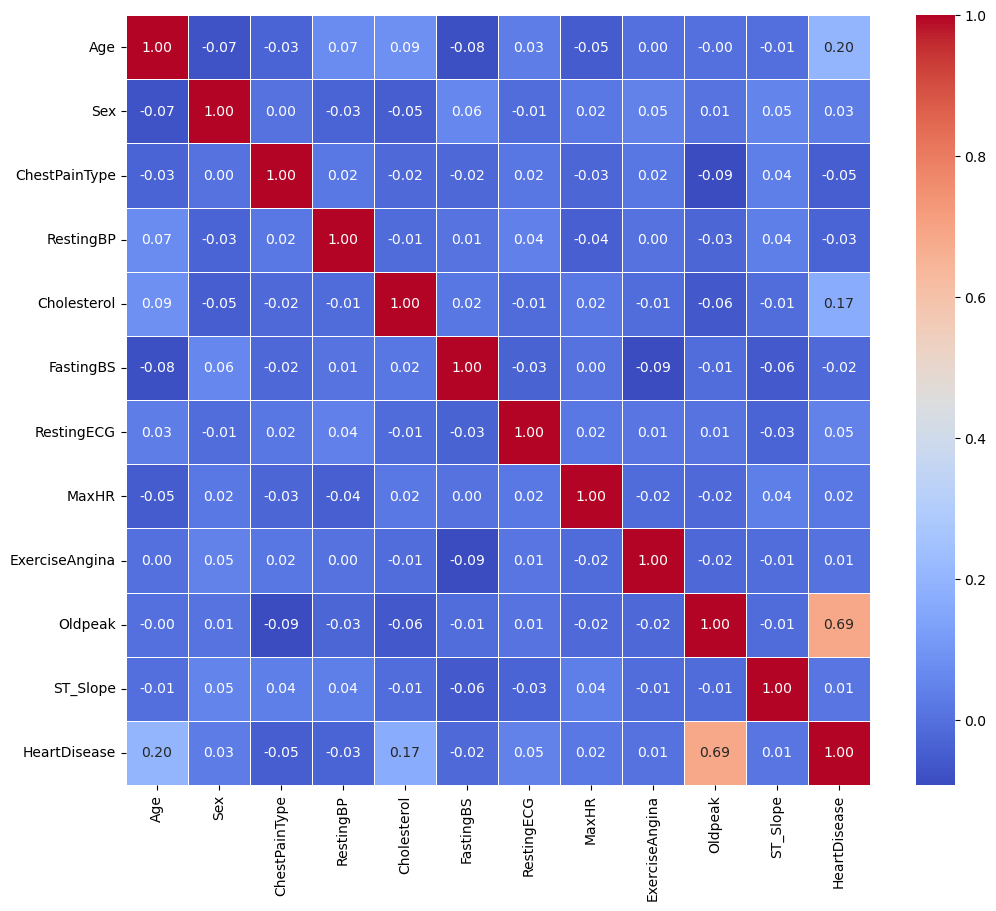

In [42]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.show()

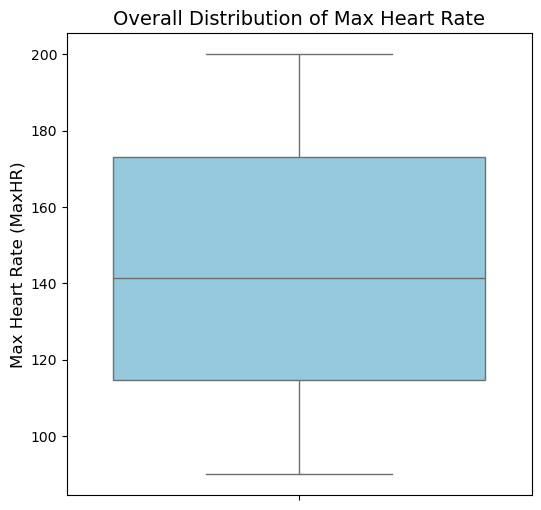

In [41]:


plt.figure(figsize=(6, 6))

sns.boxplot(y='MaxHR', data=df, color='skyblue')

plt.title('Overall Distribution of Max Heart Rate', fontsize=14)
plt.ylabel('Max Heart Rate (MaxHR)', fontsize=12)

plt.show()